In [108]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats

from sklearn.metrics import r2_score

from sklearn. preprocessing import PowerTransformer

In [109]:
df = pd.read_csv(r'C:\Users\rohit\Downloads\concrete.csv', encoding='latin-1')


In [110]:
df.shape

(1030, 9)

In [111]:
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


In [112]:
df.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

In [113]:
df.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [114]:
X=df.drop(columns=['strength'])
y=df.iloc[:,-1]

In [115]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Applying Regression without any transformation

In [116]:
lr=LinearRegression()

In [117]:
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
r2_score(y_test,y_pred)

0.6081118525118778

# Cross Checking with Cross Val score

In [118]:
lr=LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.6012883381757208)

In [119]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


 # Plotting the distplot without any transformation

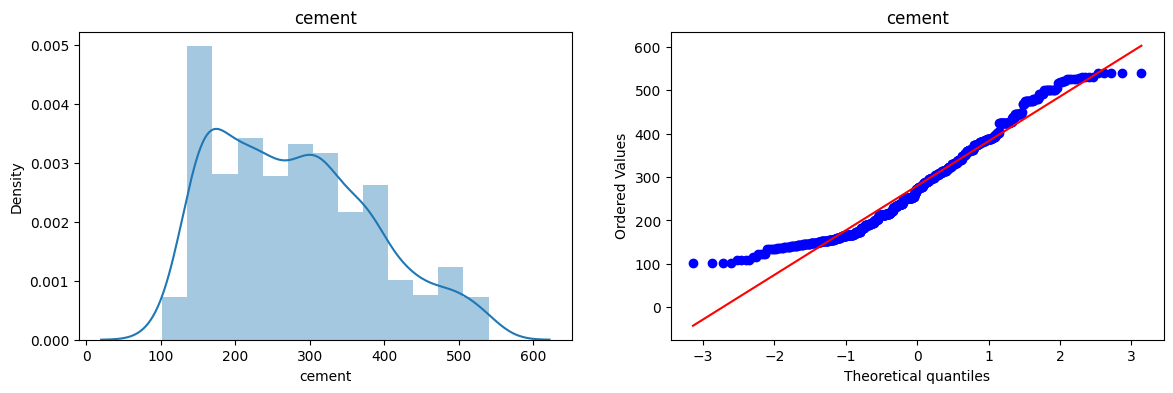

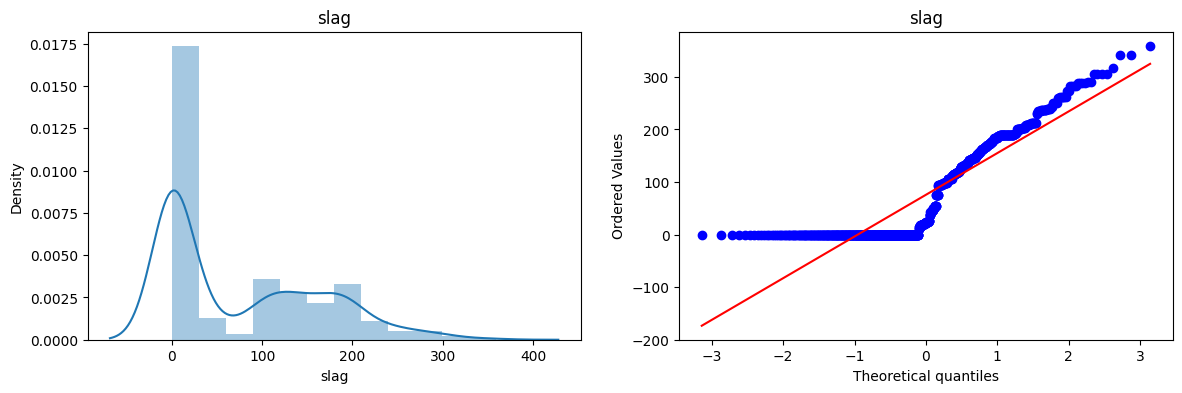

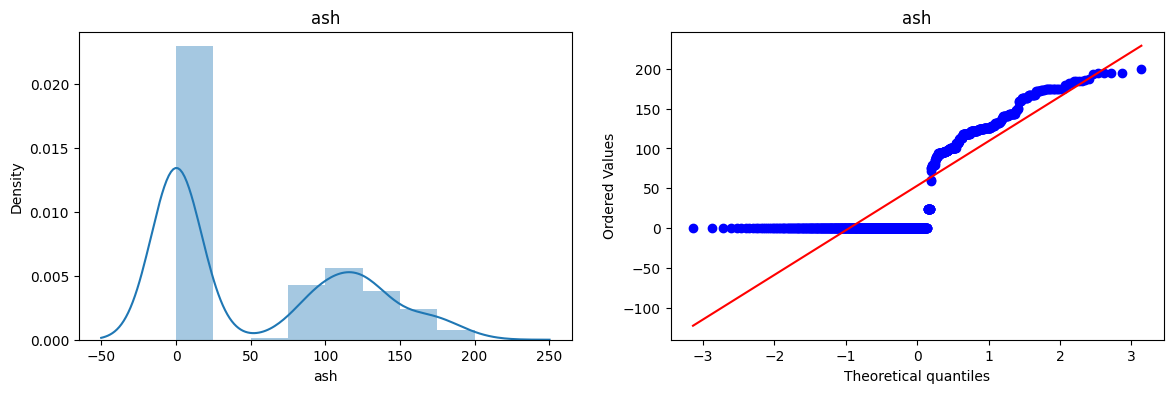

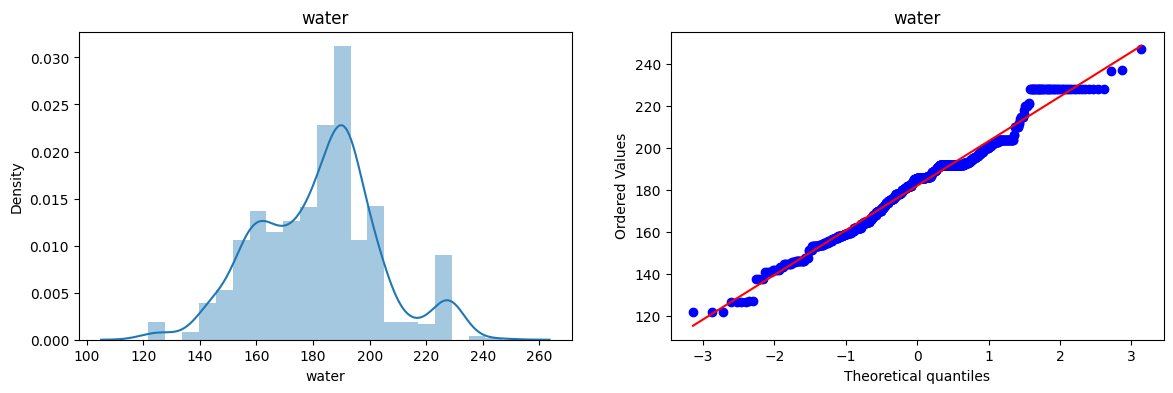

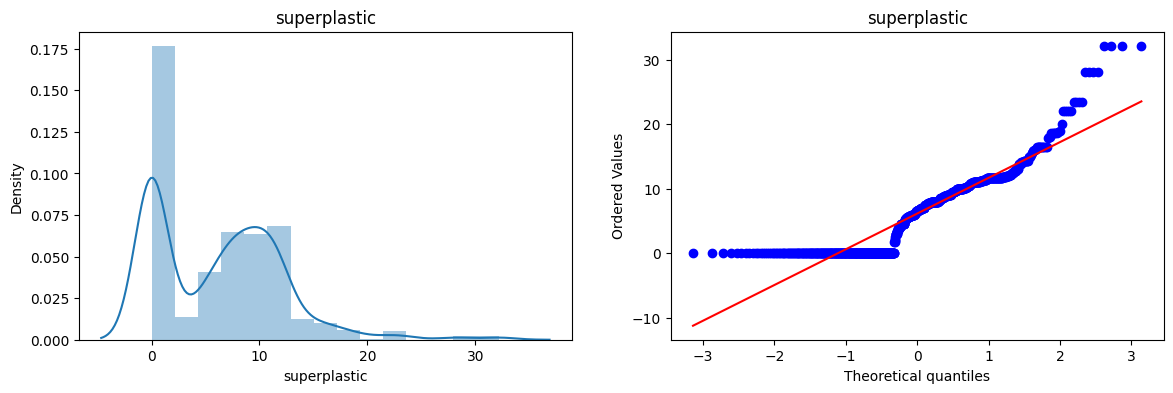

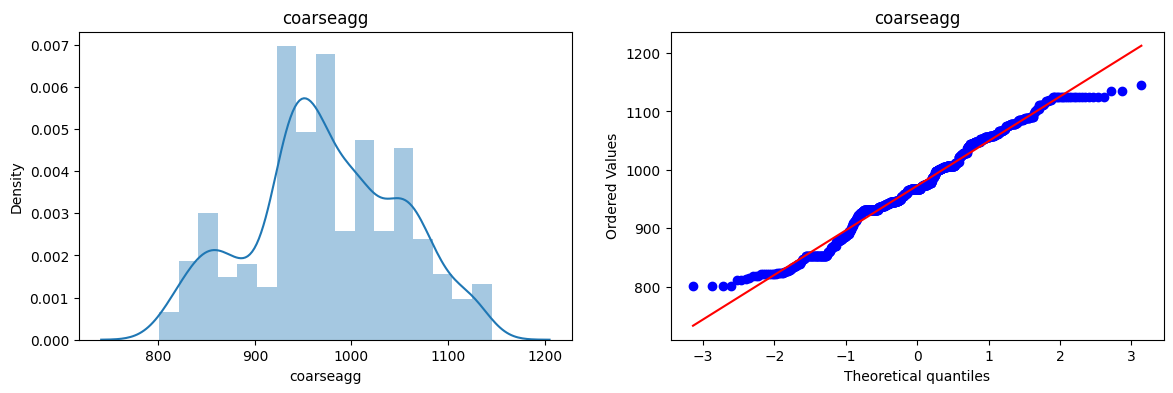

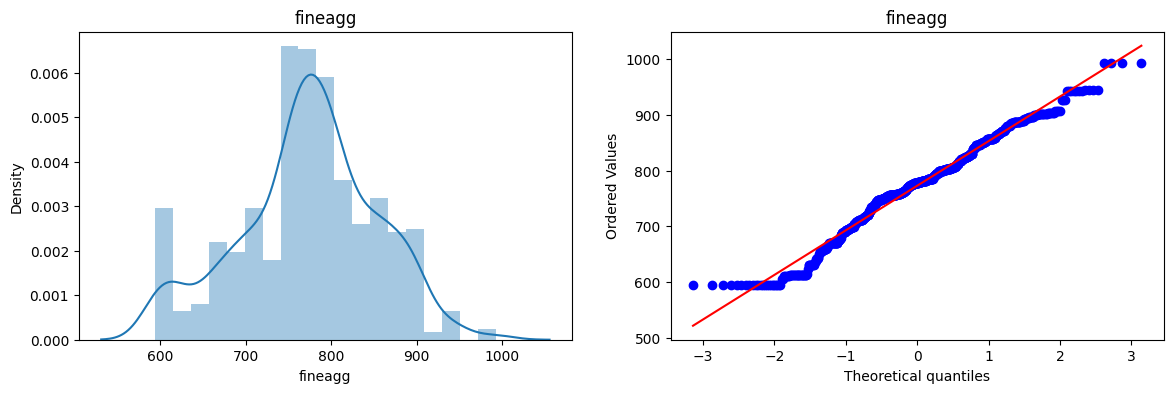

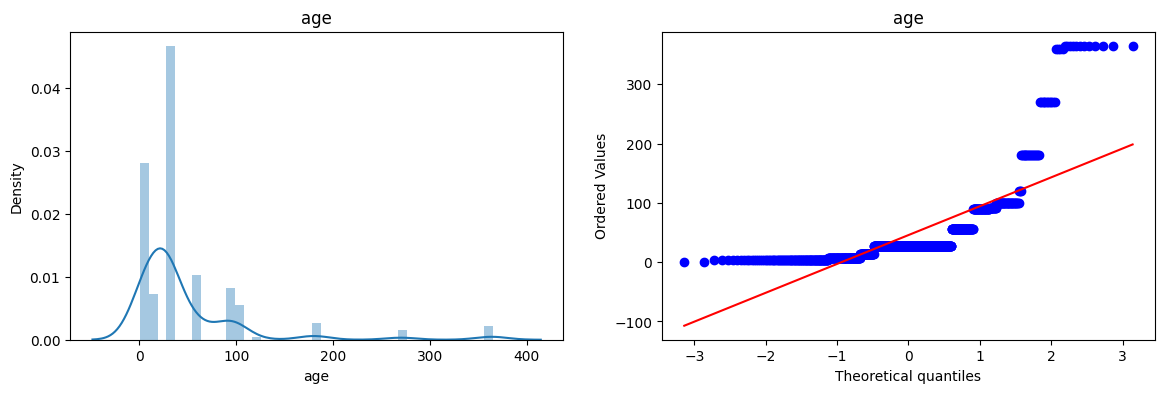

In [120]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col],kde=True)
    plt.title(col)
    plt.subplot(122)
    stats.probplot(X_train[col],dist="norm",plot=plt)
    plt.title(col)
    plt.show()

# Applying box cox transform

In [121]:
pt=PowerTransformer(method='box-cox')
X_train_transformed=pt.fit_transform(X_train+0.000001)
X_test_transformed=pt.transform(X_test+0.000001)
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})


,cols,box_cox_lambdas
0,cement,0.177515
1,slag,0.024448
2,ash,-0.037392
3,water,0.853675
4,superplastic,0.095116
5,coarseagg,1.229404
6,fineagg,1.724776
7,age,0.050641


In [122]:
X_train_transformed=pd.DataFrame(X_train_transformed,columns=X_train.columns,index=X_train.index)

In [123]:
lr=LinearRegression()
lr.fit(X_train_transformed,y_train)
y_pred2=lr.predict(X_test_transformed)
r2_score(y_test,y_pred2)

0.7820317542982471

In [124]:
pt=PowerTransformer(method='box-cox')
X_transformed=pt.fit_transform(X+0.000001)
lr=LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.7948175998905269)

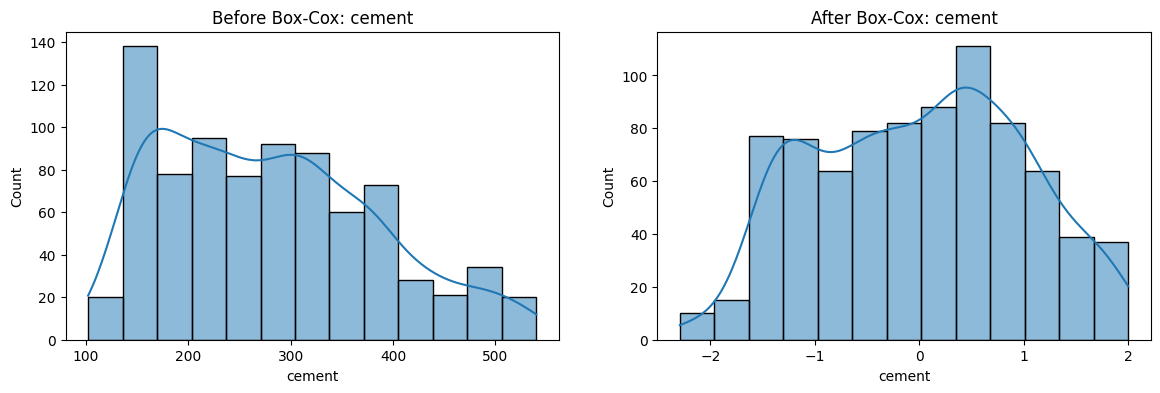

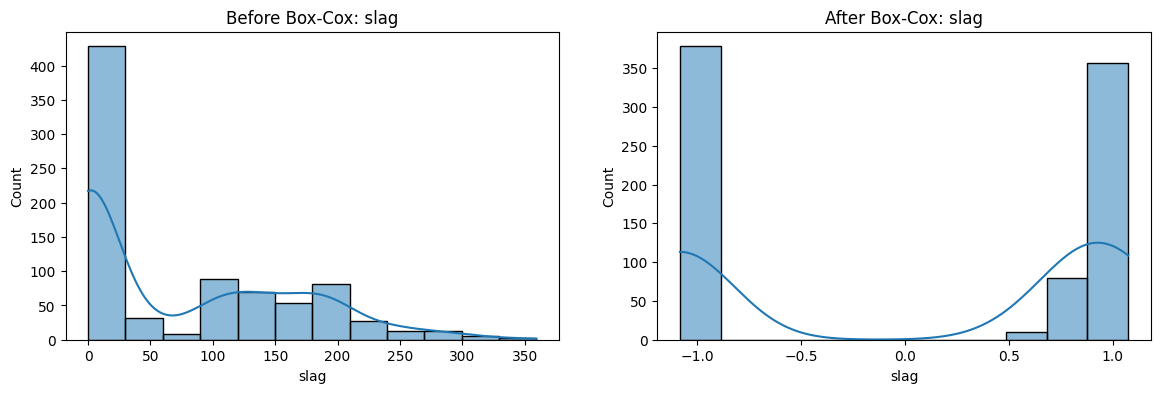

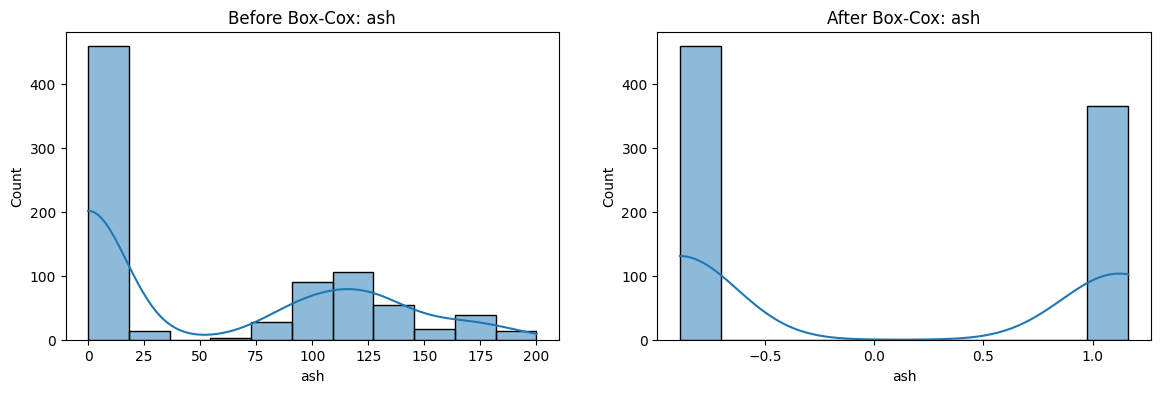

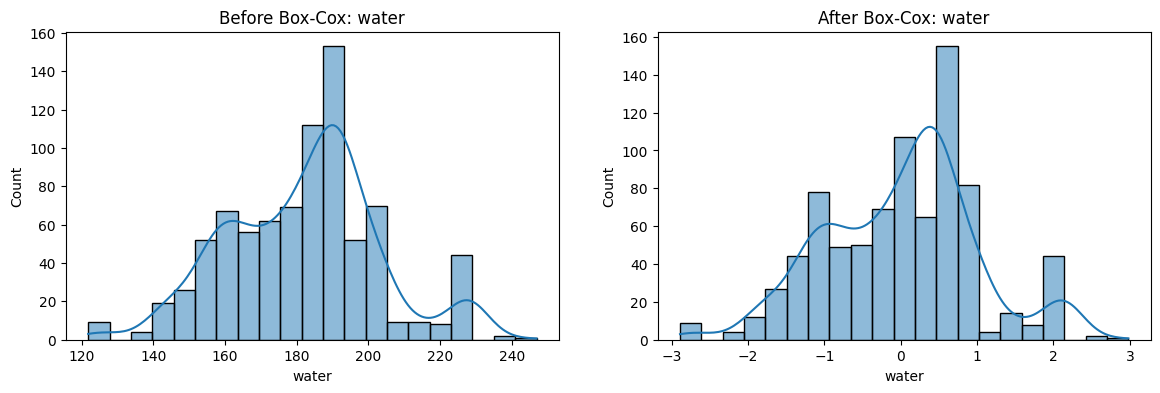

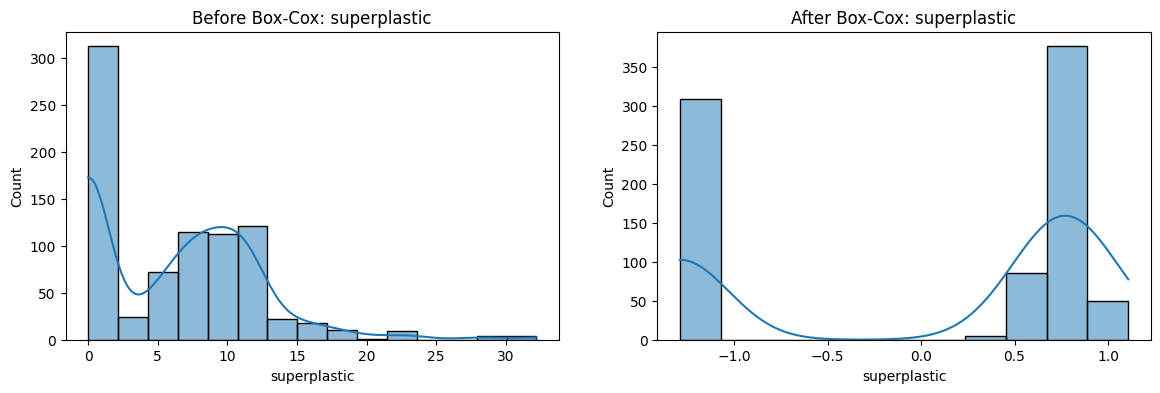

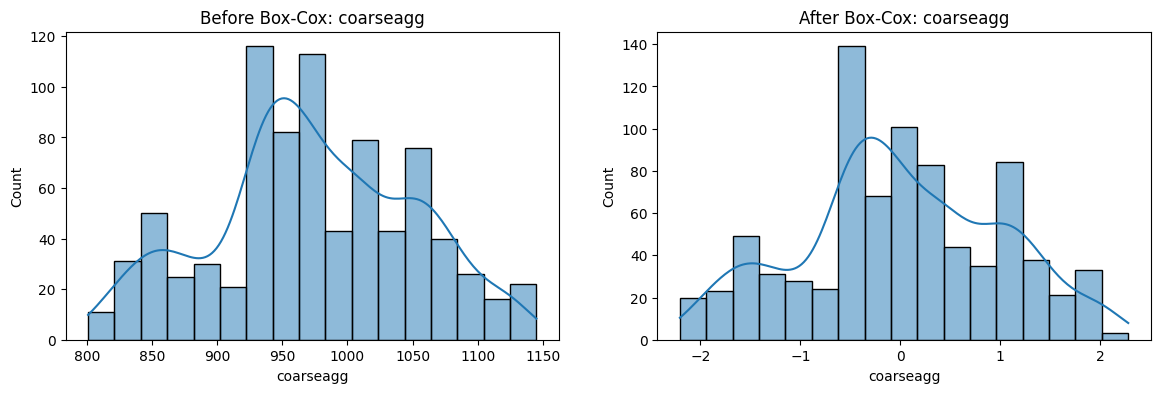

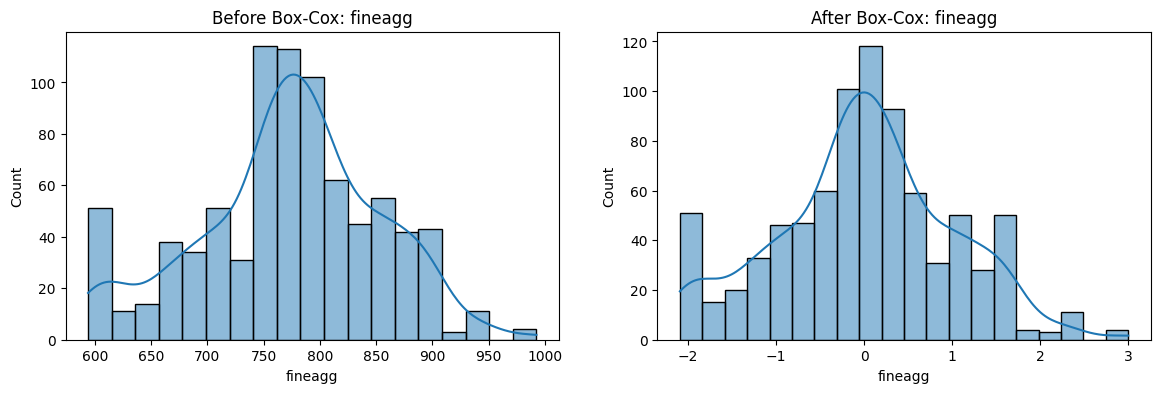

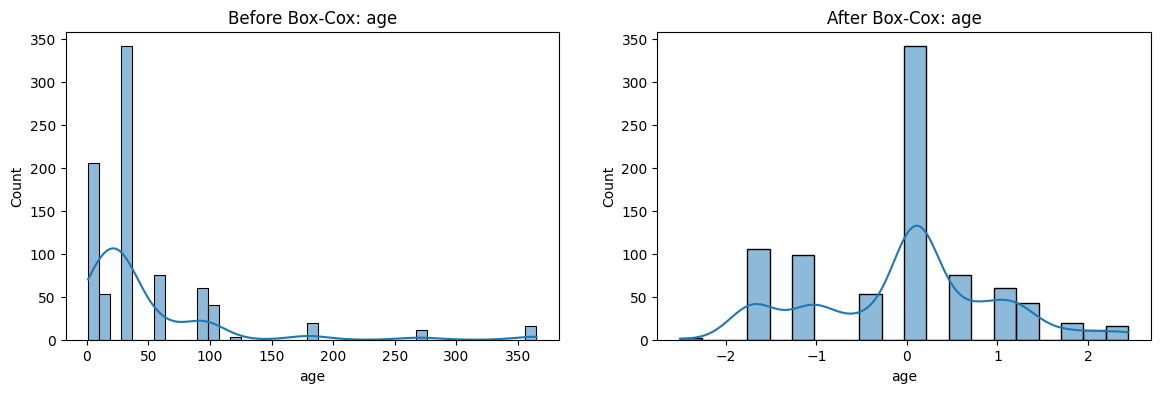

In [125]:
# Before and after comparision for Box-Cox Plot

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))

    # Before
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(f'Before Box-Cox: {col}')

    # After
    plt.subplot(122)
    sns.histplot(X_train_transformed[col], kde=True)
    plt.title(f'After Box-Cox: {col}')

    plt.show()

# Apply Yeo-Johnson Transform

In [126]:
pt1=PowerTransformer() ## Method By default Yeo Johnsom

In [127]:
X_train_transformed2=pt1.fit_transform(X_train)
X_test_transformed2=pt1.transform(X_test)

In [128]:
lr=LinearRegression()
lr.fit(X_train_transformed2,y_train)
y_pred3=lr.predict(X_test_transformed2)
print(r2_score(y_test,y_pred3))

0.7834235347986606


In [129]:
pd.DataFrame({'cols':X_train.columns,'Yeo_johnson_lambdas':pt.lambdas_})

,cols,Yeo_johnson_lambdas
0,cement,0.172271
1,slag,0.025273
2,ash,-0.032412
3,water,0.809568
4,superplastic,0.099711
5,coarseagg,1.129167
6,fineagg,1.829625
7,age,0.048975


In [130]:
# Applying cross Val score
pt1 = PowerTransformer()
X_transformed2 = pt1.fit_transform(X)

Ir = LinearRegression()
np.mean(cross_val_score(lr, X_transformed2,y, scoring='r2' ) )

np.float64(0.7989126822614582)

In [131]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns=X_train.columns)

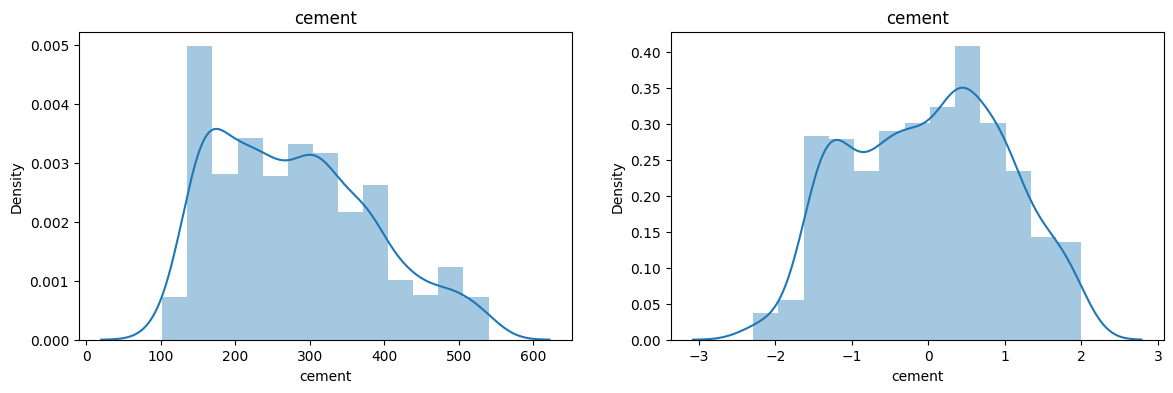

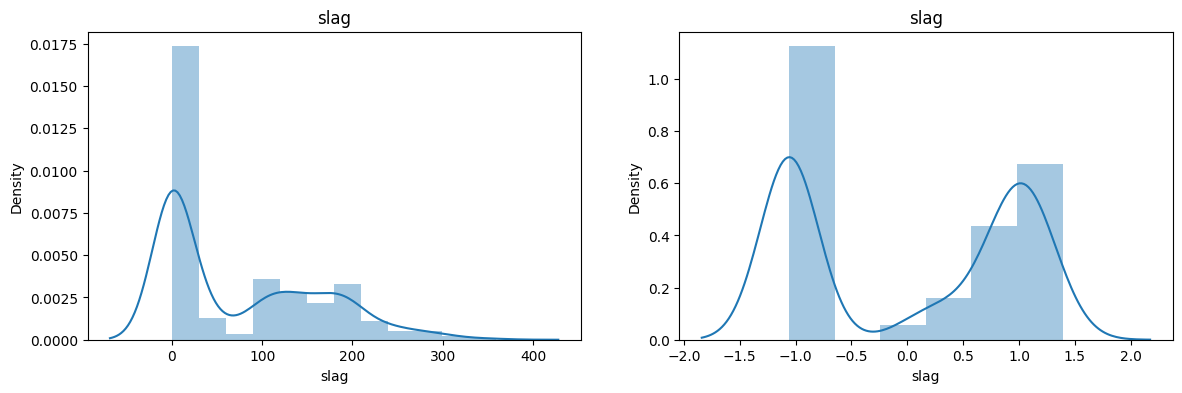

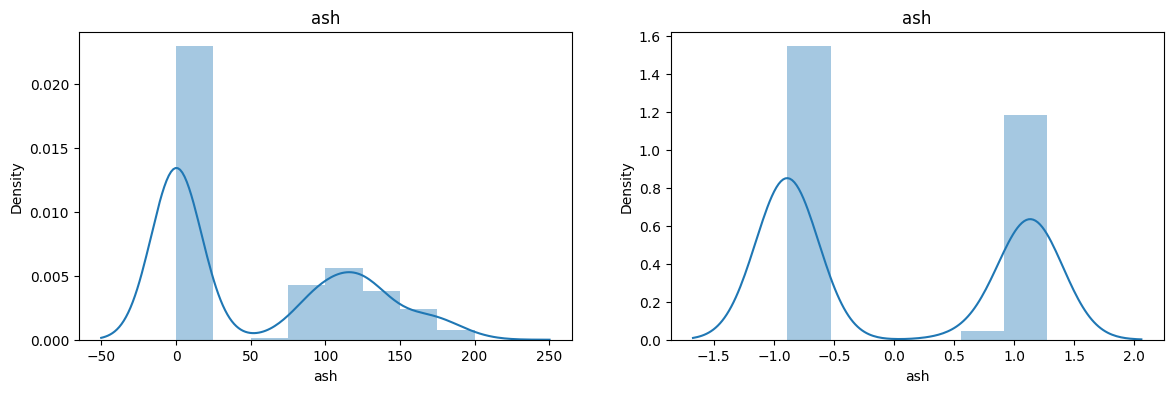

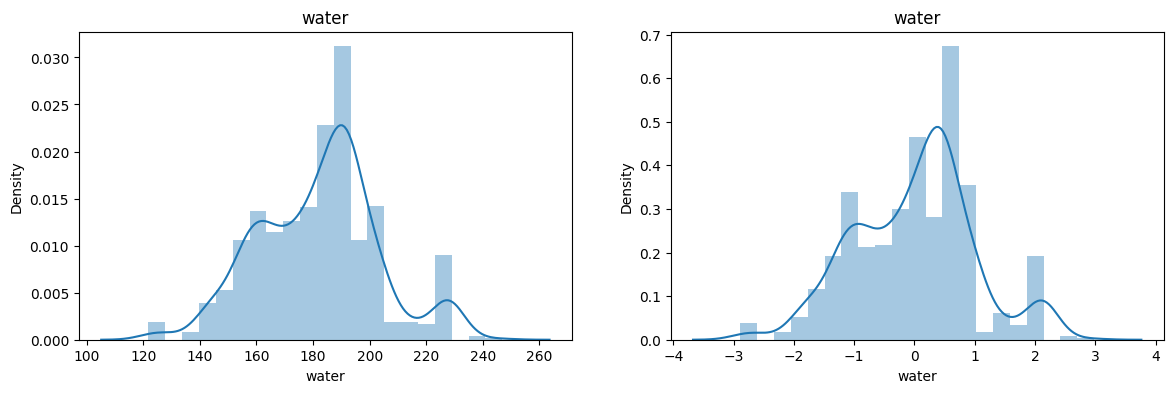

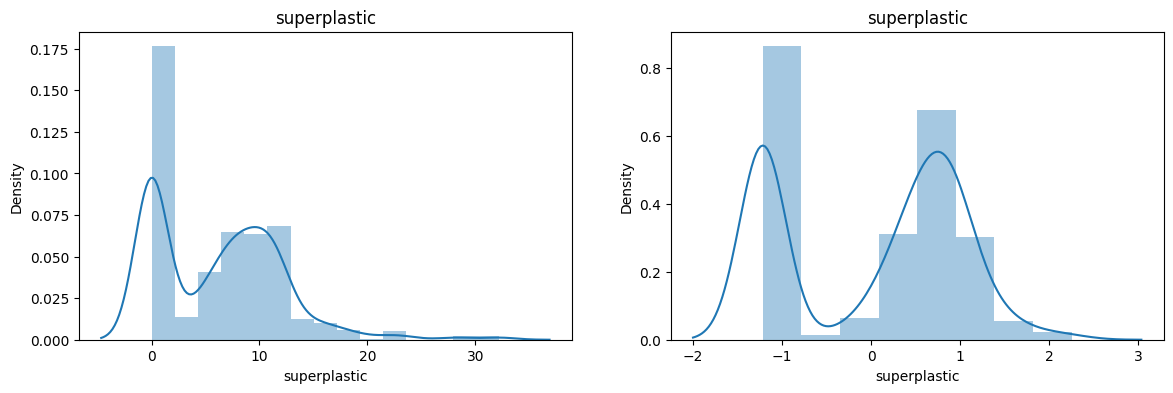

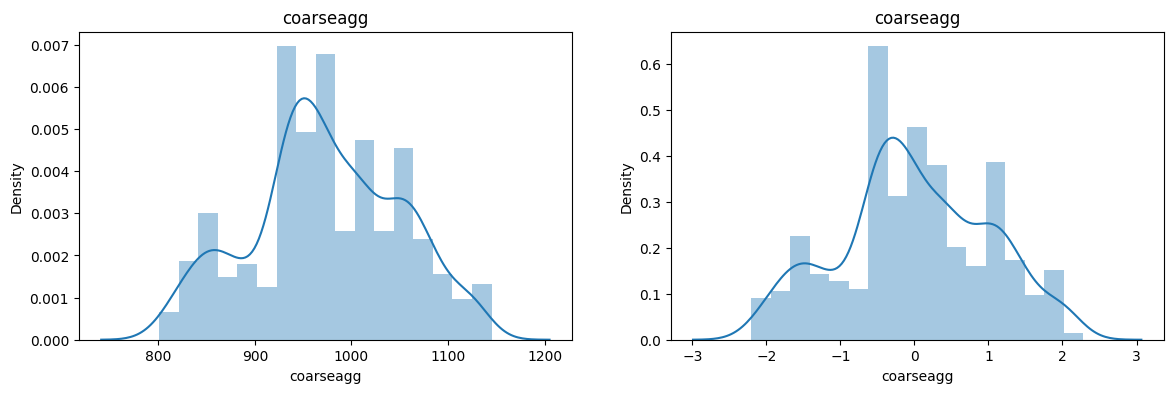

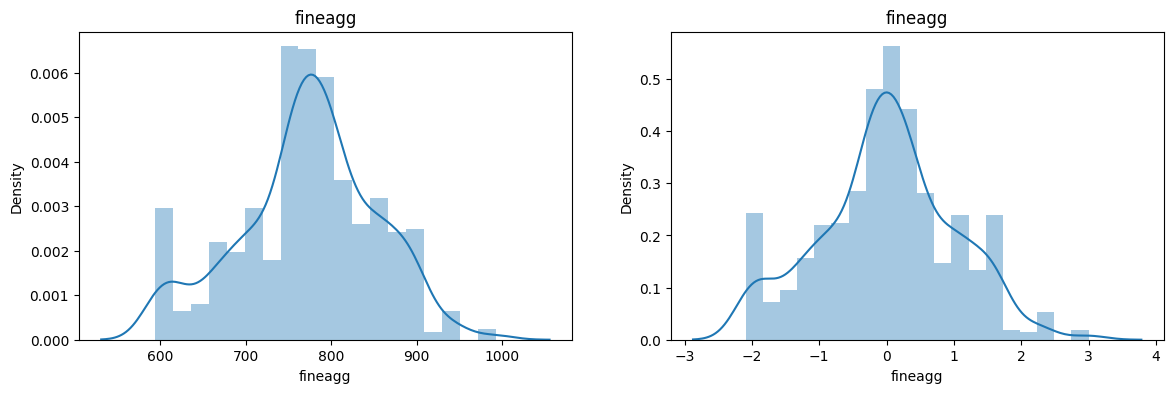

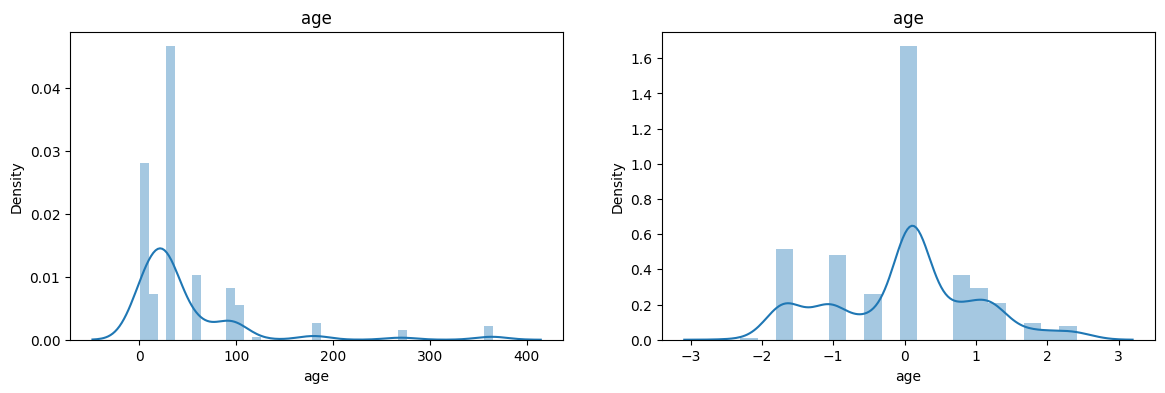

In [132]:
# Before and after comparision for Yeo-Johnson

for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)
    
    plt.subplot(122)
    sns.distplot(X_train_transformed2[col])
    plt.title(col)
    
    plt.show()

In [133]:
# Side by side Lambdas
pd.DataFrame({'columns':X_train.columns,'Bo_cox_Lambdas':pt.lambdas_,'yeo_johnson_lambdas':pt1.lambdas_})

,columns,Bo_cox_Lambdas,yeo_johnson_lambdas
0,cement,0.172271,0.169544
1,slag,0.025273,0.016633
2,ash,-0.032412,-0.136480
3,water,0.809568,0.808438
4,superplastic,0.099711,0.264160
5,coarseagg,1.129167,1.129395
6,fineagg,1.829625,1.830764
7,age,0.048975,0.001771
